# Feature Selection

## Overview

Feature selection reduces dimensionality by removing irrelevant or redundant predictors, improving model interpretability, reducing overfitting, and speeding up training. Unlike PCA/NMF, feature selection retains original features — results remain directly interpretable.

**Three families:**

| Family | Method | Pros | Cons |
|---|---|---|---|
| Filter | Correlation, mutual info, ANOVA F | Fast, model-agnostic | Ignores feature interactions |
| Wrapper | RFE, forward/backward selection | Accounts for interactions | Slow, computationally expensive |
| Embedded | LASSO, RF importance, permutation | Efficient, interaction-aware | Model-specific |

Always perform feature selection **inside** a cross-validation loop — selecting on the full dataset before splitting inflates performance estimates.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.feature_selection import (SelectKBest, f_classif, mutual_info_classif,
    RFE, RFECV, SelectFromModel)
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LassoCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score
from scipy.special import expit

rng = np.random.default_rng(42)
n, p = 250, 20
X = rng.normal(0, 1, (n, p))
true_coef = np.zeros(p)
true_coef[:6] = [2.0, -1.5, 1.2, -0.9, 0.7, -0.5]
log_odds = X @ true_coef
label = (expit(log_odds) > 0.5).astype(int)
feat_names = [f"feat_{i:02d}" for i in range(p)]
X_tr, X_te, y_tr, y_te = train_test_split(X, label, test_size=0.25,
                                            stratify=label, random_state=42)
print(f"True signal features: {[feat_names[i] for i in range(6)]}")
print(f"Noise features: {p-6}")

True signal features: ['feat_00', 'feat_01', 'feat_02', 'feat_03', 'feat_04', 'feat_05']
Noise features: 14


---
## Filter Methods: ANOVA F and Mutual Information

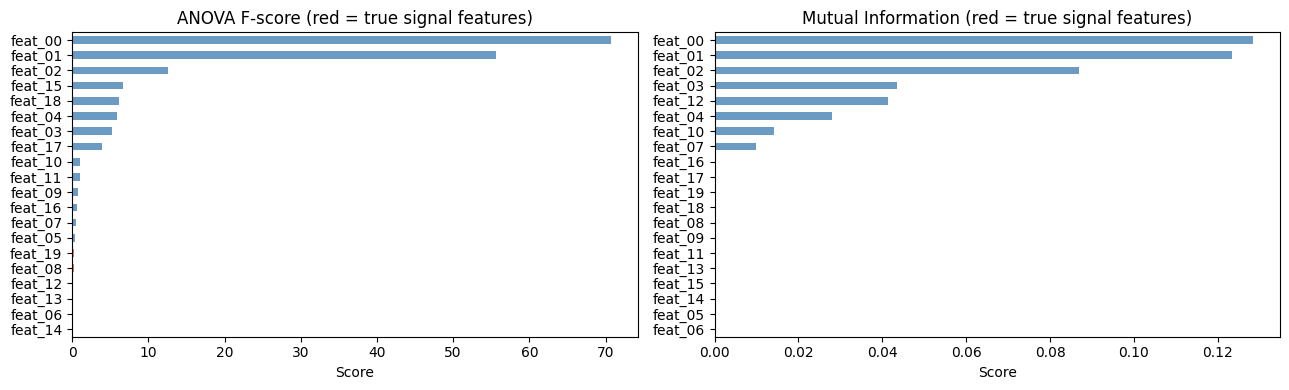

In [2]:
selector_f  = SelectKBest(f_classif,           k=8).fit(X_tr, y_tr)
selector_mi = SelectKBest(mutual_info_classif,  k=8).fit(X_tr, y_tr)
scores_f  = pd.Series(selector_f.scores_,  index=feat_names)
scores_mi = pd.Series(selector_mi.scores_, index=feat_names)
fig, axes = plt.subplots(1,2,figsize=(13,4))
for ax, scores, title in zip(axes,
    [scores_f, scores_mi], ["ANOVA F-score","Mutual Information"]):
    colors = ["#e74c3c" if i < 6 else "steelblue" for i in range(p)]
    scores.sort_values().plot(kind="barh", ax=ax, color=colors, alpha=0.8)
    ax.set_title(f"{title} (red = true signal features)")
    ax.set_xlabel("Score")
plt.tight_layout(); plt.show()

---
## Wrapper Method: RFECV

Optimal number of features: 6
Selected features: ['feat_00', 'feat_01', 'feat_02', 'feat_03', 'feat_04', 'feat_18']


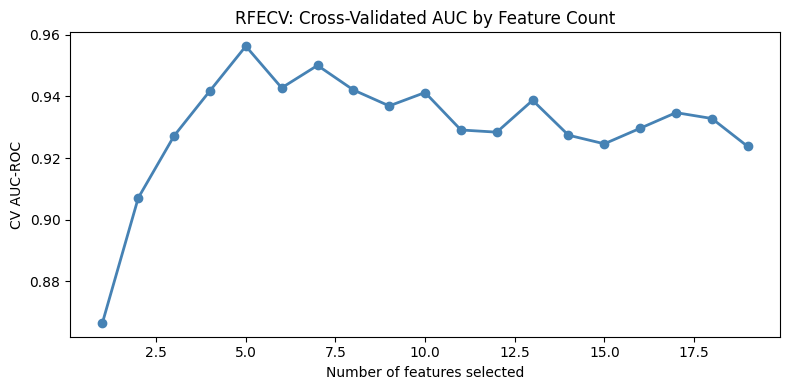

In [3]:
rf_base = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rfecv = RFECV(rf_base, step=1, cv=StratifiedKFold(5),
              scoring="roc_auc", min_features_to_select=2, n_jobs=-1)
rfecv.fit(X_tr, y_tr)
print(f"Optimal number of features: {rfecv.n_features_}")
selected = [feat_names[i] for i in range(p) if rfecv.support_[i]]
print(f"Selected features: {selected}")
plt.figure(figsize=(8,4))
plt.plot(range(1, len(rfecv.cv_results_["mean_test_score"])+1),
         rfecv.cv_results_["mean_test_score"], "o-", color="steelblue", lw=2)
plt.xlabel("Number of features selected")
plt.ylabel("CV AUC-ROC")
plt.title("RFECV: Cross-Validated AUC by Feature Count")
plt.tight_layout(); plt.show()

---
## Embedded Method: LASSO and RF Importance

LASSO selected 16 features: ['feat_00', 'feat_01', 'feat_02', 'feat_03', 'feat_04', 'feat_05', 'feat_06', 'feat_07', 'feat_09', 'feat_11', 'feat_13', 'feat_14', 'feat_15', 'feat_16', 'feat_17', 'feat_18']


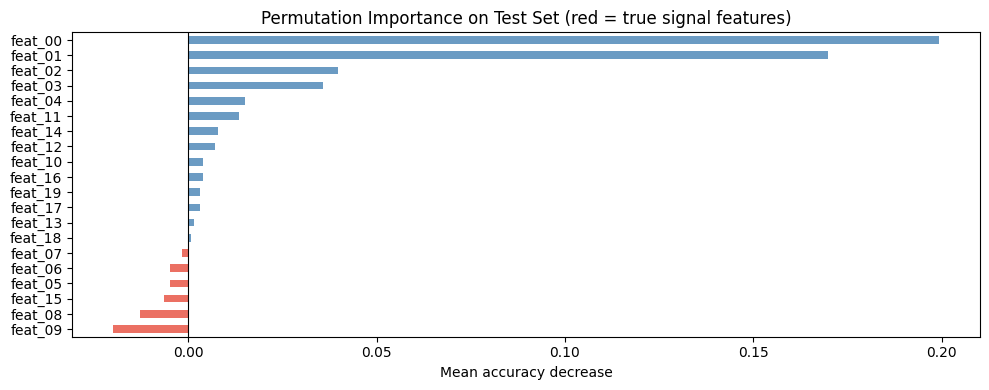

In [4]:
# LASSO embedded selection
lasso = LassoCV(cv=5, random_state=42).fit(
    StandardScaler().fit_transform(X_tr), y_tr)
lasso_sel = [feat_names[i] for i in range(p) if lasso.coef_[i] != 0]
print(f"LASSO selected {len(lasso_sel)} features: {lasso_sel}")
# RF permutation importance
from sklearn.inspection import permutation_importance
rf_full = RandomForestClassifier(n_estimators=300, random_state=42).fit(X_tr, y_tr)
perm = permutation_importance(rf_full, X_te, y_te, n_repeats=20, random_state=42)
pi = pd.Series(perm.importances_mean, index=feat_names)
fig, ax = plt.subplots(figsize=(10,4))
colors = ["#e74c3c" if i < 6 else "steelblue" for i in range(p)]
pi.sort_values().plot(kind="barh", ax=ax, color=colors, alpha=0.8)
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Permutation Importance on Test Set (red = true signal features)")
ax.set_xlabel("Mean accuracy decrease")
plt.tight_layout(); plt.show()

---
## Selection Inside Cross-Validation

In [5]:
# Correct: feature selection inside the CV pipeline
pipe_correct = Pipeline([
    ("select", SelectKBest(f_classif, k=8)),
    ("rf",     RandomForestClassifier(n_estimators=100, random_state=42))
])
cv_correct = cross_val_score(pipe_correct, X, label, cv=5, scoring="roc_auc")
print(f"Selection INSIDE CV:  AUC={cv_correct.mean():.3f} +/- {cv_correct.std():.3f}")
# Wrong: selection on all data then CV
selector_leak = SelectKBest(f_classif, k=8).fit(X, label)  # uses all data!
X_leaked = selector_leak.transform(X)
cv_leak = cross_val_score(RandomForestClassifier(n_estimators=100, random_state=42),
                          X_leaked, label, cv=5, scoring="roc_auc")
print(f"Selection OUTSIDE CV: AUC={cv_leak.mean():.3f} +/- {cv_leak.std():.3f}  <- optimistically biased")

Selection INSIDE CV:  AUC=0.957 +/- 0.031
Selection OUTSIDE CV: AUC=0.954 +/- 0.032  <- optimistically biased


---

## Common Pitfalls

**1. Performing feature selection on the full dataset before cross-validation**  
Selecting features using all n observations, then cross-validating on that reduced set, leaks test fold information into feature scores. AUC will be optimistically inflated. Always wrap feature selection inside a `Pipeline` so it runs only on training folds.

**2. Using filter methods alone for correlated feature sets**  
Filter methods evaluate features independently and cannot detect redundant features. Two highly correlated features may both score highly on ANOVA F even though only one adds information. Follow filter selection with a VIF check or use RFECV.

**3. Treating LASSO zero coefficients as definitively irrelevant**  
LASSO drops features from a correlated group arbitrarily. A feature with zero LASSO coefficient may be informative in a different model. Use stability selection or bootstrap LASSO to assess which features are consistently selected.

**4. Not re-selecting features after adding new data**  
Feature importance rankings depend on the dataset. A feature selected on 100 observations may not be selected on 500. Re-run feature selection whenever the dataset changes substantially.

**5. Comparing feature selection methods without a held-out test set**  
Compar­ing ANOVA, RFE, and LASSO by cross-validated AUC on the same dataset, then picking the best, is itself a selection step that inflates the reported performance. Designate one method based on prior reasoning or use a nested cross-validation approach.

---
*python_methods_library - Samantha McGarrigle*